# Backtester

Run all cells, then press Enter for the pendulum study or type C to test your own rules. The README explains the study and the results.

## Setup

In [41]:
import ast
import math
import re
import textwrap
from datetime import date
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
try:
    import yfinance as yf
except ImportError:
    yf = None #if yfinance not installed -> program doesn't crash and only complains when you try download data

TRADING_DAYS = 252 #rough number of days market is open per year
WARMUP_DAYS = 500 #extra calendar days downloaded before start date -> more on this in cell 2
RANDOM_RUNS = 300 #random strategies benchmark creates to compare against strategy
SENSITIVITY_STEPS = [0.5, 0.75, 1.0, 1.25, 1.5]
TUNE_STEPS = [0.8, 0.9, 1.0, 1.1, 1.25]  # how far each number is nudged when searching for better rules
TUNE_PASSES = 3
MAX_MARKERS = 200
RULE_SIDES = [("buy", "buy_rule"), ("sell", "sell_rule"), ("short", "short_rule"), ("cover", "cover_rule")]

# The pendulum written in the rule language:
#   THETA  = (PRICE - MA60) / STD60                      angle: distance from equilibrium
#   V      = THETA - THETA[1]                             velocity: dθ/dt, one day per step
#   ENERGY = COS(THETA) - V ^ 2 / (2 * 0.05)              from ½v² + (g/L)(1 - cos θ) = constant
#   TURN   = ACOS(ENERGY)                                 where the swing turns (v = 0)
# The rules below are those formulas written out in full.
_T = "(PRICE - MA60) / STD60"
_T1 = "(PRICE[1] - MA60[1]) / STD60[1]"
_T2 = "(PRICE[2] - MA60[2]) / STD60[2]"
_ENERGY = f"COS({_T}) - ({_T} - {_T1}) ^ 2 / (2 * 0.05)"

DEFAULT_STUDY = {
    "physics": """
Default study: does EUR/USD move like a pendulum?

The 60-day average is treated as the bottom of a pendulum's swing, and price as the pendulum.
  Equation of motion:  d²θ/dt² = -(g/L) · sin θ
  Energy is conserved, so a swing turns at  θ = arccos(cos θ - v² / (2·g/L))

  θ    how far price is from its 60-day average, in standard deviations
  v    how much θ changed since yesterday
  g/L  0.05, how strongly price is pulled back to the average

Buy when a swing bottoms out below -1.5 and sell where the formula says it turns on the
other side. If no turning point exists (the swing would go over the top), the average has
probably moved, so get out. Shorts are the mirror image.
Rules were set using 2005-2015 and tested on 2016 onwards.""",
    "tickers": ["EURUSD=X"],
    "start": "2005-01-01",
    "end": date.today().isoformat(),
    "split_date": "2016-01-01",
    "settings": {
        "buy_rule": f"BUY IF {_T1} < {_T2} AND {_T} > {_T1} AND {_T} < -1.5",
        "sell_rule": f"SELL IF ACOS({_ENERGY}) - {_T} < 0.2 OR {_ENERGY} < -1",
        "short_rule": f"SHORT IF {_T1} > {_T2} AND {_T} < {_T1} AND {_T} > 1.5",
        "cover_rule": f"COVER IF ACOS({_ENERGY}) + {_T} < 0.2 OR {_ENERGY} < -1",
        "size_rule": "",
        "initial": 10000,
        "cost_pct": 0.02,
        "short_fee_pct": 0.0,
        "position_pct": 100,
        "target_vol_pct": None,
        "rebalance_pct": 10,
        "stop_loss_pct": None,
        "take_profit_pct": None,
    },
}

CUSTOM_DEFAULTS = {
    "tickers": ["EURUSD=X"],
    "start": "2005-01-01",
    "split_date": "2016-01-01",
    "buy_rule": "BUY IF PRICE > MA200",
    "sell_rule": "SELL IF PRICE < MA200",
    "short_rule": "SHORT IF PRICE < MA200",
    "cover_rule": "COVER IF PRICE > MA200",
    "initial": 10000,
    "cost_pct": 0.02,
    "short_fee_pct": 0.0,
    "position_pct": 100,
    "rebalance_pct": 10,
}

HELP = """
INDICATORS (replace N with a number, at least 2)
  PRICE, MAN, EMAN, STDN, RSIN, ZSCOREN, VOLN (annual %), HIGHN / LOWN (previous N days),
  RETURN_ND (%), DIST_MAN (%), MACD, MACD_SIGNAL, DRAWDOWN (%)

OPERATORS   >  <  >=  <=  CROSSES_ABOVE  CROSSES_BELOW      combine with AND / OR

FORMULAS (both sides of a comparison can be any formula)
  + - * / ^ and brackets          (PRICE - MA60) / STD60 < -1.5
  [n] = n days ago                PRICE > PRICE[1]
  SIN COS TAN ASIN ACOS ATAN ABS SQRT LOG EXP      ABS(PRICE - MA20) > STD20
  STDN = typical distance of price from its N-day average

RULES
  BUY IF ZSCORE20 < -2
  SELL IF ZSCORE20 > 0
  BUY IF RSI14 < 30 AND PRICE > MA200
  SELL IF MA20 CROSSES_BELOW MA50 OR RSI14 > 75
  BUY IF PRICE < PRICE[1]    price fell today
  SELL IF NONE

SHORTING (optional)
  SHORT IF PRICE < MA200     bet on a fall
  COVER IF PRICE > MA200     close the short
  An opposite signal flips the position directly (long -> short or back).
  Stop loss and take profit work in both directions. Sizing rules apply to longs only.

SIZING (optional, how much to hold while the buy rule is active)
  SIZE BY ZSCORE20 FROM -1 TO -3     0% at -1, 100% at -3, in between scales linearly
  SIZE BY RSI14 FROM 40 TO 20        more RSI weakness, bigger position
  Target volatility, e.g. 15         hold less when the asset is jumpy

MODES
  Default    press Enter at the start: the pendulum study
  Quick      asks only for tickers, dates, rules and cost; everything else uses defaults.
             Shows your rule vs buy & hold, when you were in and out, what went wrong.
  Advanced   asks for every setting and adds a train/test split, 300 random strategies,
             parameter sensitivity and a search for better numbers in your rules.
"""

QUICK_DEFAULTS = {
    "size_rule": "",
    "initial": 10000,
    "position_pct": 100,
    "target_vol_pct": None,
    "rebalance_pct": 10,
    "stop_loss_pct": None,
    "take_profit_pct": None,
    "short_fee_pct": 0.0,
}

## Data

In [42]:
def load_prices(ticker, start, end):
    if yf is None:
        raise ImportError("yfinance is not installed. Run: pip install yfinance")
    buffer_start = (pd.Timestamp(start) - pd.Timedelta(days=WARMUP_DAYS)).strftime("%Y-%m-%d") #start date 500 days earlier than yours -> enough history for indicators such as MA200
    df = yf.download(ticker, start=buffer_start, end=end, auto_adjust=True, progress=False)
    if df is None or df.empty:
        raise ValueError(f"no data found for {ticker}")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df[["Open", "High", "Low", "Close"]].dropna()

## Indicators

In [43]:
def _rsi(close, window):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
    avg_loss = loss.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
    rsi = 100 - 100 / (1 + avg_gain / avg_loss)
    return rsi.where(avg_loss != 0, 100.0)


def _zscore(close, window):
    mean = close.rolling(window).mean()
    std = close.rolling(window).std()
    return (close - mean) / std


def _macd(close):
    return close.ewm(span=12, adjust=False).mean() - close.ewm(span=26, adjust=False).mean()


WINDOW_INDICATORS = [
    (r"(?:MA|SMA)(\d+)", lambda c, w: c.rolling(w).mean()),
    (r"EMA(\d+)",        lambda c, w: c.ewm(span=w, adjust=False, min_periods=w).mean()),
    (r"RSI(\d+)",        _rsi),
    (r"ZSCORE(\d+)",     _zscore),
    (r"VOL(\d+)",        lambda c, w: c.pct_change().rolling(w).std() * math.sqrt(TRADING_DAYS) * 100),
    (r"HIGH(\d+)",       lambda c, w: c.rolling(w).max().shift(1)),
    (r"LOW(\d+)",        lambda c, w: c.rolling(w).min().shift(1)),
    (r"RETURN_?(\d+)D",  lambda c, w: c.pct_change(w) * 100),
    (r"DIST_MA(\d+)",    lambda c, w: (c / c.rolling(w).mean() - 1) * 100),
    (r"STD(\d+)",        lambda c, w: c.rolling(w).std()),
    (r"DIST_HIGH(\d+)",  lambda c, w: (c / c.rolling(w).max().shift(1) - 1) * 100),
    (r"DIST_LOW(\d+)",   lambda c, w: (c / c.rolling(w).min().shift(1) - 1) * 100),
]


def get_indicator(name, close):
    n = name.upper()
    if n in ("PRICE", "CLOSE"):
        return close
    if n == "MACD":
        return _macd(close)
    if n == "MACD_SIGNAL":
        return _macd(close).ewm(span=9, adjust=False).mean()
    if n == "DRAWDOWN":
        peak = close.cummax()
        return (close - peak) / peak * 100
    for pattern, func in WINDOW_INDICATORS:
        match = re.fullmatch(pattern, n)
        if match:
            window = int(match.group(1))
            if window < 2:
                raise ValueError(f"window in {name} must be at least 2")
            return func(close, window)
    raise ValueError(f"unknown indicator '{name}'")

## Rules and formulas

In [44]:
FLIPPED = {">": "<", "<": ">", ">=": "<=", "<=": ">=",
           "CROSSES_ABOVE": "CROSSES_BELOW", "CROSSES_BELOW": "CROSSES_ABOVE"}


def _normalise(text):
    t = " ".join((text or "").strip().upper().split())
    return t.replace("CROSSES ABOVE", "CROSSES_ABOVE").replace("CROSSES BELOW", "CROSSES_BELOW")


COMPARISON = re.compile(r"CROSSES_ABOVE|CROSSES_BELOW|>=|<=|>|<")
FUNCTIONS = {"SIN": np.sin, "COS": np.cos, "TAN": np.tan, "ASIN": np.arcsin, "ACOS": np.arccos,
             "ATAN": np.arctan, "ABS": np.abs, "SQRT": np.sqrt, "LOG": np.log, "EXP": np.exp}


def parse_rule(text):
    t = re.sub(r"^(BUY|SELL|SHORT|COVER)\s+IF\s+", "", _normalise(text))
    if t in ("", "NONE"):
        return None
    groups = []
    for group_text in re.split(r"\s+OR\s+", t):
        conditions = []
        for cond_text in re.split(r"\s+AND\s+", group_text):
            match = COMPARISON.search(cond_text)
            if not match:
                raise ValueError(f"can't read '{cond_text}'. Use: FORMULA OPERATOR FORMULA, e.g. PRICE > MA200")
            left, right = cond_text[:match.start()].strip(), cond_text[match.end():].strip()
            if not left or not right:
                raise ValueError(f"'{cond_text}' needs something on both sides of {match.group()}")
            conditions.append((left, match.group(), right))
        groups.append(conditions)
    return groups


def evaluate(formula, close, cache=None):
    # turns text like "(PRICE - MA60) / STD60" into a series of values, one per day
    cache = {} if cache is None else cache
    try:
        tree = ast.parse(formula.replace("^", "**"), mode="eval").body
    except SyntaxError:
        raise ValueError(f"can't read the formula '{formula}'")

    def indicator(name):
        if name not in cache:
            cache[name] = get_indicator(name, close)
        return cache[name]

    def calc(node):
        if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
            return float(node.value)
        if isinstance(node, ast.Name):
            return indicator(node.id)
        if isinstance(node, ast.Subscript) and isinstance(node.value, ast.Name):  # MA60[1] = yesterday
            days = node.slice.value if isinstance(node.slice, ast.Constant) else None
            if not isinstance(days, int) or days < 0:
                raise ValueError("use a whole number of days in brackets, e.g. PRICE[1]")
            return indicator(node.value.id).shift(days)
        if isinstance(node, ast.UnaryOp) and isinstance(node.op, (ast.USub, ast.UAdd)):
            value = calc(node.operand)
            return -value if isinstance(node.op, ast.USub) else value
        if isinstance(node, ast.BinOp):
            a, b = calc(node.left), calc(node.right)
            ops = {ast.Add: lambda: a + b, ast.Sub: lambda: a - b, ast.Mult: lambda: a * b,
                   ast.Div: lambda: a / b, ast.Pow: lambda: a ** b}
            if type(node.op) in ops:
                return ops[type(node.op)]()
        if isinstance(node, ast.Call) and isinstance(node.func, ast.Name) and node.func.id in FUNCTIONS:
            if len(node.args) != 1:
                raise ValueError(f"{node.func.id} takes one value, e.g. {node.func.id}(PRICE)")
            return FUNCTIONS[node.func.id](calc(node.args[0]))
        raise ValueError(f"can't read part of the formula '{formula}'")

    with np.errstate(all="ignore"):  # e.g. ACOS of a number outside -1..1 gives no answer (NaN)
        result = calc(tree)
    if not isinstance(result, pd.Series):
        result = pd.Series(result, index=close.index)
    return result.replace([np.inf, -np.inf], np.nan)


def _condition(left, op, right, close, cache=None):
    a = evaluate(left, close, cache)
    b = evaluate(right, close, cache)
    valid = a.notna() & b.notna()
    if op == ">":
        result = a > b
    elif op == "<":
        result = a < b
    elif op == ">=":
        result = a >= b
    elif op == "<=":
        result = a <= b
    elif op == "CROSSES_ABOVE":
        result = (a > b) & (a.shift(1) <= b.shift(1))
    else:
        result = (a < b) & (a.shift(1) >= b.shift(1))
    return (result & valid).fillna(False).astype(bool)


def build_signal(rule_text, close):
    groups = parse_rule(rule_text)
    signal = pd.Series(False, index=close.index)
    if groups is None:
        return signal
    cache = {}
    for conditions in groups:
        group_signal = pd.Series(True, index=close.index)
        for left, op, right in conditions:
            group_signal &= _condition(left, op, right, close, cache)
        signal |= group_signal
    return signal


def flip_rule(rule_text):
    return " ".join(FLIPPED.get(token, token) for token in _normalise(rule_text).split())


def parse_size(text):
    t = _normalise(text)
    if t in ("", "NONE"):
        return None
    match = re.fullmatch(r"(?:SIZE\s+BY\s+)?(\S+)\s+FROM\s+(\S+)\s+TO\s+(\S+)", t)
    if not match:
        raise ValueError("use: SIZE BY INDICATOR FROM VALUE TO VALUE")
    low, high = float(match.group(2)), float(match.group(3))
    if low == high:
        raise ValueError("FROM and TO must be different")
    return match.group(1), low, high


def size_strength(size_rule, close):
    parsed = parse_size(size_rule)
    if parsed is None:
        return pd.Series(1.0, index=close.index)
    name, low, high = parsed
    values = get_indicator(name, close)
    return ((values - low) / (high - low)).clip(0, 1).fillna(0)


def _dummy_close():
    steps = np.random.default_rng(0).normal(0, 1, 400)
    return pd.Series(100 + np.cumsum(steps), index=pd.bdate_range("2000-01-03", periods=400))


def validate_rule(text):
    build_signal(text, _dummy_close())
    return text


def validate_size(text):
    size_strength(text, _dummy_close())
    return text

## Backtest engine

In [45]:
def _sign(x):
    return int(x > 0) - int(x < 0)


def _trade_record(trade, exit_date, reason, status, extra=0.0):
    profit = trade["flow"] + extra
    return {
        "side": trade["side"],
        "entry_date": trade["entry_date"].date(),
        "exit_date": exit_date.date(),
        "days_held": (exit_date - trade["entry_date"]).days,
        "size": round(trade["notional"], 2),
        "profit": round(profit, 2),
        "return_pct": round(profit / trade["notional"] * 100, 2) if trade["notional"] else 0.0,
        "orders": trade["orders"],
        "exit_reason": reason,
        "status": status,
    }


def run_backtest(prices, start, end, buy_rule, sell_rule, initial, cost_pct=0.1, position_pct=100.0,
                 stop_loss_pct=None, take_profit_pct=None, size_rule="", target_vol_pct=None,
                 rebalance_pct=10.0, short_rule="", cover_rule="", short_fee_pct=0.0):
    close_all = prices["Close"]
    buy_all = build_signal(buy_rule, close_all)
    sell_all = build_signal(sell_rule, close_all)
    short_all = build_signal(short_rule, close_all)
    cover_all = build_signal(cover_rule, close_all)
    strength_all = size_strength(size_rule, close_all)
    if target_vol_pct:
        vol = get_indicator("VOL20", close_all)
        vol_scale_all = (target_vol_pct / vol).clip(upper=1).fillna(0)
    else:
        vol_scale_all = pd.Series(1.0, index=close_all.index)

    window = (prices.index >= pd.Timestamp(start)) & (prices.index < pd.Timestamp(end))
    dates = prices.index[window]
    if len(dates) < 30:
        raise ValueError(f"only {len(dates)} trading days between {start} and {end}")
    opens = prices["Open"][window].to_numpy(dtype=float)
    close = close_all[window].to_numpy(dtype=float)
    buy_sig = buy_all[window].to_numpy()
    sell_sig = sell_all[window].to_numpy()
    short_sig = short_all[window].to_numpy()
    cover_sig = cover_all[window].to_numpy()
    strength = strength_all[window].to_numpy(dtype=float)
    vol_scale = vol_scale_all[window].to_numpy(dtype=float)

    cost = cost_pct / 100
    fee = (short_fee_pct or 0.0) / 100 / TRADING_DAYS  # borrow fee per day on the short position
    base = min(position_pct, 100) / 100
    threshold = rebalance_pct / 100
    stop = stop_loss_pct / 100 if stop_loss_pct else None
    gain_target = take_profit_pct / 100 if take_profit_pct else None

    cash, shares, avg_price = float(initial), 0.0, 0.0  # shares < 0 means short
    side, target, exit_reason = 0, 0.0, ""  # side: 1 long, -1 short, 0 out
    trade, trades, values, weights = None, [], [], []

    for i, day in enumerate(dates):
        # ---- at the open: trade towards yesterday's target ----
        price_open = opens[i]
        equity = cash + shares * price_open
        if equity <= 0:
            side, target, exit_reason = 0, 0.0, "account wiped out"
        current = shares * price_open / equity if equity > 0 else 0.0

        if shares != 0 and (target == 0 or _sign(target) != _sign(shares)):
            value = shares * price_open
            cash += value - abs(value) * cost
            trade["flow"] += value - abs(value) * cost
            trade["orders"] += 1
            trades.append(_trade_record(trade, day, exit_reason, "closed"))
            shares, trade, current = 0.0, None, 0.0
            equity = cash

        if target != 0 and (shares == 0 or abs(target - current) > threshold):
            change = target * equity - shares * price_open
            if change > 0:
                change /= 1 + cost  # leave room for the cost so cash doesn't go negative
            delta = change / price_open
            if shares == 0:
                trade = {"side": "long" if target > 0 else "short", "entry_date": day,
                         "notional": 0.0, "flow": 0.0, "orders": 0}
                avg_price = price_open
            elif _sign(delta) == _sign(shares):
                avg_price = (avg_price * abs(shares) + price_open * abs(delta)) / (abs(shares) + abs(delta))
            if _sign(change) == _sign(target):
                trade["notional"] += abs(change)
            cash -= change + abs(change) * cost
            trade["flow"] -= change + abs(change) * cost
            trade["orders"] += 1
            shares += delta

        # ---- at the close: fees, then signals for tomorrow ----
        price = close[i]
        if shares < 0 and fee:
            charge = -shares * price * fee
            cash -= charge
            trade["flow"] -= charge

        exited = 0
        if side != 0:
            holding = shares != 0 and _sign(shares) == side
            move = side * (price / avg_price - 1) if holding else 0.0
            reason = None
            if holding and stop is not None and move <= -stop:
                reason = "stop loss"
            elif holding and gain_target is not None and move >= gain_target:
                reason = "take profit"
            elif side == 1 and sell_sig[i]:
                reason = "sell rule"
            elif side == -1 and cover_sig[i]:
                reason = "cover rule"
            elif side == 1 and short_sig[i]:
                reason = "flipped to short"
            elif side == -1 and buy_sig[i]:
                reason = "flipped to long"
            if reason:
                exited, side, exit_reason = side, 0, reason
        if side == 0:
            if buy_sig[i] and exited != 1:
                side = 1
            elif short_sig[i] and exited != -1:
                side = -1

        if side == 1:
            target = base * strength[i] * vol_scale[i]
        elif side == -1:
            target = -base * vol_scale[i]
        else:
            target = 0.0
        if side != 0 and target == 0 and not exited:
            exit_reason = "sized down to 0%"

        value = cash + shares * price
        values.append(value)
        weights.append(shares * price / value if value > 0 else 0.0)

    if shares != 0:
        trades.append(_trade_record(trade, dates[-1], "still open", "open", extra=shares * close[-1]))

    close_series = pd.Series(close, index=dates)
    strategy = pd.Series(values, index=dates)
    buy_hold = initial * (1 - cost) / opens[0] * close_series
    trades_df = pd.DataFrame(trades)
    weight_series = pd.Series(weights, index=dates)
    return {
        "start": dates[0].date(), "end": dates[-1].date(), "initial": initial,
        "close": close_series, "strategy": strategy, "buy_hold": buy_hold,
        "weights": weight_series, "trades": trades_df,
        "metrics": performance(strategy, initial),
        "bh_metrics": performance(buy_hold, initial),
        "stats": trade_stats(trades_df, weight_series),
        "yearly": period_returns(strategy, buy_hold, "Y"),
        "monthly": period_returns(strategy, buy_hold, "M"),
    }

## Performance

In [46]:
def performance(values, initial):
    daily = values.pct_change().fillna(0)
    final = values.iloc[-1]
    years = max((values.index[-1] - values.index[0]).days / 365.25, 1 / 365.25)
    std = daily.std()
    drawdown = (values / values.cummax() - 1) * 100
    return {
        "final": final,
        "total_return": (final / initial - 1) * 100,
        "cagr": ((final / initial) ** (1 / years) - 1) * 100 if final > 0 else -100.0,
        "volatility": std * math.sqrt(TRADING_DAYS) * 100,
        "sharpe": daily.mean() / std * math.sqrt(TRADING_DAYS) if std > 0 else 0.0,
        "max_drawdown": drawdown.min(),
        "drawdown": drawdown,
    }


def trade_stats(trades_df, weights):
    base = {"avg_invested": weights.abs().mean() * 100,
            "time_in_market": (weights != 0).mean() * 100,
            "time_long": (weights > 0).mean() * 100,
            "time_short": (weights < 0).mean() * 100}
    closed = trades_df[trades_df["status"] == "closed"] if not trades_df.empty else trades_df
    if closed.empty:
        return {**base, "trades": 0, "long_trades": 0, "short_trades": 0, "orders": 0, "win_rate": 0.0,
                "avg_win": 0.0, "avg_loss": 0.0, "profit_factor": 0.0, "avg_days": 0.0, "best": 0.0,
                "worst": 0.0, "top_trade_share": 0.0}
    wins = closed[closed["profit"] > 0]
    losses = closed[closed["profit"] <= 0]
    gross_loss = -losses["profit"].sum()
    total_profit = closed["profit"].sum()
    top_share = wins["profit"].max() / total_profit * 100 if total_profit > 0 and not wins.empty else 0.0
    return {
        **base,
        "trades": len(closed),
        "long_trades": int((closed["side"] == "long").sum()),
        "short_trades": int((closed["side"] == "short").sum()),
        "orders": int(trades_df["orders"].sum()),
        "win_rate": len(wins) / len(closed) * 100,
        "avg_win": wins["return_pct"].mean() if not wins.empty else 0.0,
        "avg_loss": losses["return_pct"].mean() if not losses.empty else 0.0,
        "profit_factor": wins["profit"].sum() / gross_loss if gross_loss > 0 else float("inf"),
        "avg_days": closed["days_held"].mean(),
        "best": closed["return_pct"].max(),
        "worst": closed["return_pct"].min(),
        "top_trade_share": top_share,
    }


def _resample(series, kind):
    for code in {"Y": ["YE", "Y"], "M": ["ME", "M"]}[kind]:
        try:
            return (1 + series).resample(code).prod() - 1
        except (ValueError, KeyError):
            continue
    raise ValueError("could not resample returns")


def period_returns(strategy, buy_hold, kind):
    table = pd.DataFrame({
        "strategy_%": _resample(strategy.pct_change().fillna(0), kind) * 100,
        "buy_hold_%": _resample(buy_hold.pct_change().fillna(0), kind) * 100,
    }).round(2)
    table["difference_%"] = (table["strategy_%"] - table["buy_hold_%"]).round(2)
    table.index = table.index.year if kind == "Y" else table.index.strftime("%Y-%m")
    return table

## Random benchmark

In [47]:
def _holding_blocks(weights):
    blocks, run, current = [], 0, 0  # each block: (length, +1 long / -1 short)
    for w in weights.to_numpy():
        s = int(np.sign(w))
        if s != 0 and s == current:
            run += 1
            continue
        if current != 0:
            blocks.append((run, current))
        run, current = (1, s) if s != 0 else (0, 0)
    if current != 0:
        blocks.append((run, current))
    return blocks


def _simple_returns(weights, asset_returns, cost, fee=0.0):
    held = np.concatenate([[0.0], weights[:-1]])
    turnover = np.abs(np.diff(np.concatenate([[0.0], weights])))
    borrow = np.where(held < 0, -held * fee, 0.0)
    return held * asset_returns - turnover * cost - borrow


def _total_and_sharpe(returns):
    std = returns.std()
    sharpe = returns.mean() / std * math.sqrt(TRADING_DAYS) if std > 0 else 0.0
    return (np.prod(1 + returns) - 1) * 100, sharpe


def random_benchmark(result, cost_pct, short_fee_pct=0.0, runs=RANDOM_RUNS, seed=42):
    weights = result["weights"]
    blocks = _holding_blocks(weights)
    if not blocks:
        return None
    level = weights[weights != 0].abs().mean()
    asset_returns = result["close"].pct_change().fillna(0).to_numpy()
    cost = cost_pct / 100
    fee = (short_fee_pct or 0.0) / 100 / TRADING_DAYS
    n = len(weights)
    free_days = n - sum(length for length, _ in blocks)
    rng = np.random.default_rng(seed)

    own_return, own_sharpe = _total_and_sharpe(_simple_returns(weights.to_numpy(), asset_returns, cost, fee))
    returns, sharpes = [], []
    for _ in range(runs):
        order = rng.permutation(len(blocks))
        gaps = rng.multinomial(free_days, np.ones(len(blocks) + 1) / (len(blocks) + 1))
        fake = np.zeros(n)
        position = gaps[0]
        for j, gap in zip(order, gaps[1:]):
            length, direction = blocks[j]
            fake[position:position + length] = direction * level
            position += length + gap
        total, sharpe = _total_and_sharpe(_simple_returns(fake, asset_returns, cost, fee))
        returns.append(total)
        sharpes.append(sharpe)

    returns, sharpes = np.array(returns), np.array(sharpes)
    return {
        "runs": runs,
        "own_return": own_return,
        "own_sharpe": own_sharpe,
        "random_returns": returns,
        "random_median_return": float(np.median(returns)),
        "return_beaten_pct": float((returns < own_return).mean() * 100),
        "sharpe_beaten_pct": float((sharpes < own_sharpe).mean() * 100),
    }

## Parameter sensitivity

In [48]:
WINDOW_TOKEN = re.compile(r"\b([A-Z_]+?)(\d+)(D?)\b")
NUMBER_TOKEN = re.compile(r"(?<![A-Z_\d.])-?\d+(?:\.\d+)?(?![\d.])")


def find_parameters(rule_text):
    # every tunable number in a rule: indicator windows (MA60) and thresholds (-1.5)
    text = _normalise(rule_text)
    found = []
    for m in WINDOW_TOKEN.finditer(text):
        found.append({"span": m.span(), "kind": "window", "value": int(m.group(2)),
                      "prefix": m.group(1), "suffix": m.group(3), "label": m.group(0)})
    for m in NUMBER_TOKEN.finditer(text):
        before, after = text[:m.start()].rstrip(), text[m.end():].lstrip()
        if before.endswith("[") or before.endswith("^"):
            continue  # days in PRICE[1] and powers like ^ 2 are part of the formula, not settings
        if after.startswith("*") and "." not in m.group(0):
            continue  # whole-number factors like the 2 in "2 * 0.05"
        found.append({"span": m.span(), "kind": "threshold", "value": float(m.group(0)),
                      "label": text[max(0, m.start() - 12):m.end()].strip()})
    return found


def parameter_values(param):
    value = param["value"]
    if param["kind"] == "window":
        return sorted({max(2, int(round(value * step))) for step in SENSITIVITY_STEPS})
    if value == 0:
        return [-1.0, -0.5, 0.0, 0.5, 1.0]
    return [round(value * step, 4) for step in SENSITIVITY_STEPS]


def tune_values(param, value):
    if param["kind"] == "window":
        return sorted({max(2, int(round(value * step))) for step in TUNE_STEPS})
    if value == 0:
        return [-0.5, -0.25, 0.0, 0.25, 0.5]
    digits = 1 if abs(value) >= 1 else (2 if abs(value) >= 0.1 else 3)  # keep numbers readable
    return sorted({round(value * step, digits) for step in TUNE_STEPS})


def rule_dials(settings):
    # the same number used in several places is one dial, e.g. every 60 in "MA60 ... STD60"
    dials = {}
    for _, key in RULE_SIDES:
        for p in find_parameters(settings.get(key, "")):
            dials.setdefault((p["kind"], p["value"]), []).append((key, p))
    return dials


def dial_label(dial, members):
    kind, value = dial
    if kind == "window":
        return f"{value}-day window"
    rules = [key.split("_")[0].upper() for key in dict.fromkeys(k for k, _ in members)]
    return f"{value:g} in {', '.join(rules)}"


def rules_with(settings, dials, values):
    rules = {}
    for _, key in RULE_SIDES:
        rule = settings.get(key, "")
        if not isinstance(rule, str) or not rule:
            continue
        text = _normalise(rule)
        edits = []
        for dial, members in dials.items():
            for member_key, p in members:
                if member_key == key:
                    v = values[dial]
                    new = f"{p['prefix']}{int(v)}{p['suffix']}" if p["kind"] == "window" else f"{v:g}"
                    edits.append((p["span"], new))
        for (start, end), new in sorted(edits, reverse=True):
            text = text[:start] + new + text[end:]
        rules[key] = text
    return rules


def sensitivity(prices, start, end, settings):
    dials = rule_dials(settings)
    if not dials:
        return None
    original = {dial: dial[1] for dial in dials}

    def sharpe_with(changes):
        trial = {**settings, **rules_with(settings, dials, {**original, **changes})}
        try:
            return run_backtest(prices, start, end, **trial)["metrics"]["sharpe"]
        except Exception:
            return np.nan

    baseline = run_backtest(prices, start, end, **settings)
    bh_sharpe = baseline["bh_metrics"]["sharpe"]
    original_sharpe = baseline["metrics"]["sharpe"]

    rows, neighbours = [], []
    for dial, members in dials.items():
        param = members[0][1]
        values = parameter_values(param)
        sharpes = [original_sharpe if v == dial[1] else sharpe_with({dial: v}) for v in values]
        rows.append({"label": dial_label(dial, members), "values": values, "sharpes": sharpes,
                     "original": dial[1]})
        neighbours += [s for v, s in zip(values, sharpes) if v != dial[1] and not np.isnan(s)]

    grid = None
    if len(dials) >= 2:
        (da, ma), (db, mb) = list(dials.items())[:2]
        values_a, values_b = parameter_values(ma[0][1]), parameter_values(mb[0][1])
        matrix = np.array([[sharpe_with({da: va, db: vb}) for vb in values_b] for va in values_a])
        grid = {"label_a": dial_label(da, ma), "values_a": values_a, "original_a": da[1],
                "label_b": dial_label(db, mb), "values_b": values_b, "original_b": db[1],
                "matrix": matrix}

    stable = float(np.mean([s > bh_sharpe for s in neighbours]) * 100) if neighbours else 0.0
    return {"rows": rows, "grid": grid, "bh_sharpe": bh_sharpe, "original_sharpe": original_sharpe,
            "stable_pct": stable, "tested": len(neighbours)}

## Searching for better numbers

In [49]:
def improve_rules(prices, start, end, settings, split_date, full, test, min_trades=10):
    dials = rule_dials(settings)
    if not dials:
        return None
    pick_end = split_date or end

    def score(values):
        trial = {**settings, **rules_with(settings, dials, values)}
        try:
            r = run_backtest(prices, start, pick_end, **trial)
        except Exception:
            return None
        return r["metrics"]["sharpe"] if r["stats"]["trades"] >= min_trades else None

    original = {dial: dial[1] for dial in dials}
    best_values = dict(original)
    yours = score(original)
    best = yours if yours is not None else -np.inf
    for _ in range(TUNE_PASSES):
        improved = False
        for dial in dials:
            param = dials[dial][0][1]
            for v in tune_values(param, best_values[dial]):
                if v == best_values[dial]:
                    continue
                candidate = {**best_values, dial: v}
                sharpe = score(candidate)
                if sharpe is not None and sharpe > best + 0.01:
                    best, best_values, improved = sharpe, candidate, True
        if not improved:
            break

    if best_values == original:
        return {"better": False}
    better_rules = rules_with(settings, dials, best_values)
    improved_full = run_backtest(prices, start, end, **{**settings, **better_rules})
    out = {"better": True, "rules": better_rules, "yours": full, "improved": improved_full,
           "split": bool(split_date)}
    if split_date:
        out["improved_test"] = run_backtest(prices, split_date, end, **{**settings, **better_rules})
        out["your_test"] = test
    return out

## Analysis and verdict

In [50]:
def analyse_ticker(prices, start, end, settings, split_date=None, advanced=True):
    full = run_backtest(prices, start, end, **settings)
    no_cost = run_backtest(prices, start, end, **{**settings, "cost_pct": 0.0, "short_fee_pct": 0.0})
    train = test = random = sens = variants = None
    if advanced:
        if split_date:
            train = run_backtest(prices, start, split_date, **settings)
            test = run_backtest(prices, split_date, end, **settings)
        random = random_benchmark(full, settings["cost_pct"], settings.get("short_fee_pct", 0.0))
        sens = sensitivity(prices, start, end, settings)
        variants = improve_rules(prices, start, end, settings, split_date, full, test)
    label, notes = verdict(full, no_cost, train, test, random, sens)
    return {"full": full, "no_cost": no_cost, "train": train, "test": test, "random": random,
            "sens": sens, "variants": variants, "label": label, "notes": notes, "advanced": advanced}


def verdict(full, no_cost=None, train=None, test=None, random=None, sens=None):
    s, b, st = full["metrics"], full["bh_metrics"], full["stats"]
    notes, score = [], 0

    if st["trades"] < 10:
        notes.append(f"Only {st['trades']} trades, too few to judge")
        score -= 1

    if s["total_return"] > b["total_return"]:
        notes.append(f"Beat buy & hold ({s['total_return']:.1f}% vs {b['total_return']:.1f}%)")
        score += 1
    else:
        notes.append(f"Lost to buy & hold ({s['total_return']:.1f}% vs {b['total_return']:.1f}%)")
        score -= 1

    if s["sharpe"] > b["sharpe"]:
        notes.append(f"Better Sharpe ({s['sharpe']:.2f} vs {b['sharpe']:.2f})")
        score += 1
    else:
        notes.append(f"Worse Sharpe ({s['sharpe']:.2f} vs {b['sharpe']:.2f})")
        score -= 1

    if s["max_drawdown"] > b["max_drawdown"]:
        notes.append(f"Smaller max drawdown ({s['max_drawdown']:.1f}% vs {b['max_drawdown']:.1f}%)")
        score += 1

    if st["avg_invested"] < 50:
        notes.append(f"Only {st['avg_invested']:.0f}% invested on average")

    if no_cost is not None:
        eaten = no_cost["metrics"]["total_return"] - s["total_return"]
        notes.append(f"Costs took {eaten:.1f} points of return")
        if no_cost["metrics"]["total_return"] > b["total_return"] >= s["total_return"]:
            notes.append("Only beats buy & hold before costs")
            score -= 1

    if st["top_trade_share"] > 50:
        notes.append(f"One trade made {st['top_trade_share']:.0f}% of the profit")
        score -= 1

    if train is not None and test is not None:
        tr_beat = train["metrics"]["total_return"] > train["bh_metrics"]["total_return"]
        te_beat = test["metrics"]["total_return"] > test["bh_metrics"]["total_return"]
        if tr_beat and te_beat:
            notes.append("Beat buy & hold in both the train and test period")
            score += 2
        elif tr_beat:
            notes.append("Worked in the train period, failed in the test period")
            score -= 2
        elif te_beat:
            notes.append("Failed in the train period, worked in the test period")
        else:
            notes.append("Lost to buy & hold in both periods")
            score -= 1

    if random is not None:
        beaten = random["sharpe_beaten_pct"]
        notes.append(f"Beat {beaten:.0f}% of {random['runs']} random strategies")
        if beaten >= 95:
            score += 2
        elif beaten < 50:
            score -= 2
        elif beaten < 75:
            score -= 1

    if sens is not None and sens["tested"]:
        stable = sens["stable_pct"]
        notes.append(f"{stable:.0f}% of {sens['tested']} nearby settings beat buy & hold")
        if stable >= 70:
            score += 1
        elif sens["original_sharpe"] > sens["bh_sharpe"] and stable < 40:
            score -= 2

    if score >= 4:
        label = "promising"
    elif score >= 0:
        label = "mixed"
    else:
        label = "doesn't hold up"
    return label, notes

## Printed output

In [51]:
def money(x):
    return f"{x:,.2f}"


def indent(text, spaces=4):
    return textwrap.indent(text, " " * spaces)


def describe(value, unit="", off="off"):
    return off if value in (None, "") else f"{value}{unit}"


def shorting_on(settings):
    return parse_rule(settings.get("short_rule", "")) is not None


def print_settings(tickers, start, end, settings, split_date, advanced):
    s = settings
    print("\nSettings")
    print(f"  Mode:            {'advanced' if advanced else 'quick'}")
    print(f"  Tickers:         {', '.join(tickers)}")
    print(f"  Period:          {start} to {end}")
    if advanced:
        print(f"  Split:           {describe(split_date, off='none')}")
    print(f"  Buy:             {s['buy_rule']}")
    print(f"  Sell:            {s['sell_rule']}")
    if shorting_on(s):
        print(f"  Short:           {s['short_rule']}")
        print(f"  Cover:           {describe(s.get('cover_rule'), off='none')}")
        print(f"  Borrow fee:      {s.get('short_fee_pct', 0)}% a year")
    else:
        print("  Shorting:        off")
    print(f"  Cost per trade:  {s['cost_pct']}%")
    print(f"  Starting money:  {s['initial']:,.0f}")
    if advanced:
        print(f"  Sizing:          {describe(s['size_rule'], off='fixed')}")
        print(f"  Max invested:    {s['position_pct']}%")
        print(f"  Target vol:      {describe(s['target_vol_pct'], '%')}")
        print(f"  Rebalance band:  {s['rebalance_pct']}%")
        print(f"  Stop loss:       {describe(s['stop_loss_pct'], '%')}")
        print(f"  Take profit:     {describe(s['take_profit_pct'], '%')}")


def print_rule_check(ticker, r, settings):
    trades = r["full"]["trades"]
    if trades.empty:
        print("No trades: the rules never opened a position.")
        return False
    if shorting_on(settings) and not (trades["side"] == "short").any():
        print("Note: the short rule never triggered.")
    if r["test"] is not None and r["test"]["trades"].empty:
        print("Note: no trades in the test period.")
    return True


def print_report(ticker, r):
    full = r["full"]
    s, b, st = full["metrics"], full["bh_metrics"], full["stats"]
    print(f"\n{ticker}, {full['start']} to {full['end']}")
    print(f"{'':18}{'Strategy':>12}{'Buy & hold':>14}")
    rows = [
        ("Final value", money(s["final"]), money(b["final"])),
        ("Total return", f"{s['total_return']:.2f}%", f"{b['total_return']:.2f}%"),
        ("Per year", f"{s['cagr']:.2f}%", f"{b['cagr']:.2f}%"),
        ("Volatility", f"{s['volatility']:.2f}%", f"{b['volatility']:.2f}%"),
        ("Sharpe", f"{s['sharpe']:.2f}", f"{b['sharpe']:.2f}"),
        ("Max drawdown", f"{s['max_drawdown']:.2f}%", f"{b['max_drawdown']:.2f}%"),
    ]
    for name, a, c in rows:
        print(f"{name:18}{a:>12}{c:>14}")

    pf = "inf" if st["profit_factor"] == float("inf") else f"{st['profit_factor']:.2f}"
    print(f"\nTrades: {st['trades']} ({st['long_trades']} long, {st['short_trades']} short), "
          f"win rate {st['win_rate']:.1f}%, profit factor {pf}")
    print(f"Avg win {st['avg_win']:.2f}%, avg loss {st['avg_loss']:.2f}%, "
          f"best {st['best']:.2f}%, worst {st['worst']:.2f}%")
    print(f"Avg {st['avg_days']:.1f} days per trade, long {st['time_long']:.0f}% of days, "
          f"short {st['time_short']:.0f}%, out {100 - st['time_in_market']:.0f}%")

    if r["train"] is not None:
        print("\nTrain vs test")
        for name, part in (("Train", r["train"]), ("Test", r["test"])):
            m, bm = part["metrics"], part["bh_metrics"]
            print(f"  {name:6}{part['start']} to {part['end']}   strategy {m['total_return']:7.2f}% "
                  f"(Sharpe {m['sharpe']:.2f})   buy & hold {bm['total_return']:7.2f}% (Sharpe {bm['sharpe']:.2f})")

    if r["random"] is not None:
        rnd = r["random"]
        print(f"\nRandom benchmark: beat {rnd['sharpe_beaten_pct']:.0f}% of {rnd['runs']} random strategies "
              f"(median random return {rnd['random_median_return']:.2f}%)")

    if r["sens"] is not None:
        sens = r["sens"]
        print(f"\nSensitivity (Sharpe, * = current, buy & hold = {sens['bh_sharpe']:.2f})")
        for row in sens["rows"]:
            cells = []
            for v, sh in zip(row["values"], row["sharpes"]):
                mark = "*" if v == row["original"] else ""
                cells.append(f"{v:g}{mark}: {sh:.2f}" if not np.isnan(sh) else f"{v:g}{mark}: n/a")
            print(f"  {row['label']:22}" + "   ".join(cells))

    if r["advanced"]:
        yearly = full["yearly"].rename(columns={"strategy_%": "Strategy %", "buy_hold_%": "Buy & hold %",
                                                "difference_%": "Difference"})
        print("\nBy year")
        print(indent(yearly.to_string(), 2))


def print_breakdown(r, top_n=10):
    full = r["full"]
    close, weights, trades = full["close"], full["weights"], full["trades"]
    market = close.pct_change().fillna(0)
    held = weights.shift(1).fillna(0)  # position held during each day's move (close to close, roughly)
    long_d, short_d, out_d = held > 0, held < 0, held == 0

    def moved(mask):
        return ((1 + market[mask]).prod() - 1) * 100

    print("\nMarket move while")
    if long_d.any():
        print(f"  long:   {moved(long_d):+.1f}%")
    if short_d.any():
        print(f"  short:  {moved(short_d):+.1f}%")
    if out_d.mean() > 0.01:  # ignore the odd warm-up day
        print(f"  out:    {moved(out_d):+.1f}%")

    def where(idx):
        parts = [f"long {int(long_d[idx].sum())}"]
        if short_d.any():
            parts.append(f"short {int(short_d[idx].sum())}")
        if out_d.mean() > 0.01:
            parts.append(f"out {int(out_d[idx].sum())}")
        return ", ".join(parts)

    print(f"Best {top_n} days: {where(market.nlargest(top_n).index)}")
    print(f"Worst {top_n} days: {where(market.nsmallest(top_n).index)}")

    closed = trades[trades["status"] == "closed"]
    if not closed.empty:
        by_reason = (closed.groupby(["side", "exit_reason"])
                     .agg(trades=("profit", "size"), avg_return=("return_pct", "mean"),
                          total_profit=("profit", "sum"))
                     .round(2))
        print("\nExits")
        print(indent(by_reason.to_string(), 2))

        cols = ["side", "entry_date", "exit_date", "days_held", "return_pct", "exit_reason"]
        print("\nWorst trades")
        print(indent(closed.nsmallest(3, "return_pct")[cols].to_string(index=False), 2))


def print_improvement(v):
    if v is None:
        return
    if not v["better"]:
        print("\nNo better numbers found nearby.")
        return

    period = "the train period" if v["split"] else "the full period"
    print(f"\nBetter numbers (picked on {period}):")
    for rule in v["rules"].values():
        print(f"  {rule}")

    yours, imp = v["yours"], v["improved"]
    print(f"\n{'':18}{'Yours':>10}{'Improved':>12}{'Buy & hold':>14}")
    ym, im, bm = yours["metrics"], imp["metrics"], imp["bh_metrics"]
    rows = [
        ("Total return", f"{ym['total_return']:.1f}%", f"{im['total_return']:.1f}%", f"{bm['total_return']:.1f}%"),
        ("Sharpe", f"{ym['sharpe']:.2f}", f"{im['sharpe']:.2f}", f"{bm['sharpe']:.2f}"),
        ("Max drawdown", f"{ym['max_drawdown']:.1f}%", f"{im['max_drawdown']:.1f}%", f"{bm['max_drawdown']:.1f}%"),
        ("Trades", f"{yours['stats']['trades']}", f"{imp['stats']['trades']}", "-"),
    ]
    for name, a, b, c in rows:
        print(f"{name:18}{a:>10}{b:>12}{c:>14}")
    if v["split"]:
        it, yt = v["improved_test"]["metrics"], v["your_test"]["metrics"]
        print(f"Test period only: Sharpe {it['sharpe']:.2f} improved vs {yt['sharpe']:.2f} yours")


def print_verdict(r):
    print(f"\nVerdict: {r['label']}")
    for note in r["notes"]:
        print(f"  {note}")


def summary_row(ticker, r):
    full = r["full"]
    return {
        "Ticker": ticker,
        "Return %": round(full["metrics"]["total_return"], 1),
        "B&H %": round(full["bh_metrics"]["total_return"], 1),
        "Sharpe": round(full["metrics"]["sharpe"], 2),
        "B&H Sharpe": round(full["bh_metrics"]["sharpe"], 2),
        "Max DD %": round(full["metrics"]["max_drawdown"], 1),
        "Trades": full["stats"]["trades"],
        "Beats random %": round(r["random"]["sharpe_beaten_pct"]) if r["random"] else None,
        "Verdict": r["label"],
    }


def print_summary(rows):
    if len(rows) < 2:
        return
    print("\nSummary")
    print(pd.DataFrame(rows).dropna(axis=1, how="all").to_string(index=False))

## Charts

In [52]:
def plot_results(ticker, r, split_date=None, compact=False):
    full = r["full"]
    close, weights, trades = full["close"], full["weights"], full["trades"]
    has_shorts = bool((weights < 0).any())
    ratios = [2, 2] if compact else [2, 2, 1, 1]
    fig, axes = plt.subplots(len(ratios), 1, figsize=(13, 7 if compact else 12), sharex=True,
                             gridspec_kw={"height_ratios": ratios})
    price_ax, equity_ax = axes[0], axes[1]

    price_ax.plot(close.index, close.values, color="black", linewidth=1, label="Price")
    price_ax.fill_between(close.index, 0, 1, where=(weights > 0).to_numpy(), step="post",
                          transform=price_ax.get_xaxis_transform(), color="green", alpha=0.15, label="Long")
    if has_shorts:
        price_ax.fill_between(close.index, 0, 1, where=(weights < 0).to_numpy(), step="post",
                              transform=price_ax.get_xaxis_transform(), color="red", alpha=0.15, label="Short")
    if not trades.empty and len(trades) <= MAX_MARKERS:
        longs = pd.to_datetime(trades.loc[trades["side"] == "long", "entry_date"])
        shorts = pd.to_datetime(trades.loc[trades["side"] == "short", "entry_date"])
        exits = pd.to_datetime(trades.loc[trades["status"] == "closed", "exit_date"])
        price_ax.scatter(longs, close.reindex(longs).values, marker="^", color="green", s=50, zorder=3,
                         label="Buy")
        if len(shorts):
            price_ax.scatter(shorts, close.reindex(shorts).values, marker="v", color="red", s=50, zorder=3,
                             label="Short")
        price_ax.scatter(exits, close.reindex(exits).values, marker="x", color="black", s=40, zorder=3,
                         label="Close position")
    title = "green = long, red = short" if has_shorts else "green = invested"
    price_ax.set_title(f"{ticker}: price ({title})")
    price_ax.legend(loc="upper left")

    equity_ax.plot(full["strategy"].index, full["strategy"].values, label="Strategy", linewidth=1.5)
    equity_ax.plot(full["buy_hold"].index, full["buy_hold"].values, label="Buy & hold",
                   color="red", linestyle="--")
    equity_ax.set_title("Portfolio value")
    equity_ax.legend(loc="upper left")

    if not compact:
        weight_ax, dd_ax = axes[2], axes[3]
        pct = weights * 100
        weight_ax.fill_between(pct.index, pct.clip(lower=0).values, step="post", color="green", alpha=0.4)
        weight_ax.fill_between(pct.index, pct.clip(upper=0).values, step="post", color="red", alpha=0.4)
        weight_ax.set_ylim(-105 if has_shorts else 0, 105)
        weight_ax.axhline(0, color="black", linewidth=0.5)
        weight_ax.set_title("% of money invested (negative = short)" if has_shorts else "% of money invested")

        dd = full["metrics"]["drawdown"]
        bh_dd = full["bh_metrics"]["drawdown"]
        dd_ax.plot(dd.index, dd.values, label="Strategy")
        dd_ax.plot(bh_dd.index, bh_dd.values, color="red", linestyle="--", label="Buy & hold")
        dd_ax.set_title("Drawdown (%)")
        dd_ax.legend(loc="lower left")

    if split_date:
        for ax in axes:
            ax.axvline(pd.Timestamp(split_date), color="grey", linestyle=":")

    plt.tight_layout()
    return fig


def plot_checks(ticker, r):
    rnd, sens = r["random"], r["sens"]
    grid = sens["grid"] if sens else None
    panels = [p for p in (rnd, grid) if p is not None]
    if not panels:
        return None
    fig, axes = plt.subplots(1, len(panels), figsize=(7 * len(panels), 5.5))
    axes = np.atleast_1d(axes)
    i = 0

    if rnd is not None:
        ax = axes[i]
        ax.hist(rnd["random_returns"], bins=30, color="grey", alpha=0.7, label="Random strategies")
        ax.axvline(rnd["own_return"], color="blue", linewidth=2, label="Your rule")
        ax.set_title(f"Your rule vs {rnd['runs']} random strategies")
        ax.set_xlabel("Total return (%)")
        ax.legend()
        i += 1

    if grid is not None:
        ax = axes[i]
        matrix = grid["matrix"]
        centre = sens["bh_sharpe"]
        low = min(np.nanmin(matrix), centre - 0.01)
        high = max(np.nanmax(matrix), centre + 0.01)
        image = ax.imshow(matrix, cmap="RdYlGn", origin="lower", aspect="auto",
                          norm=TwoSlopeNorm(vmin=low, vcenter=centre, vmax=high))
        ax.set_xticks(range(len(grid["values_b"])), [f"{v:g}" for v in grid["values_b"]])
        ax.set_yticks(range(len(grid["values_a"])), [f"{v:g}" for v in grid["values_a"]])
        ax.set_xlabel(grid["label_b"])
        ax.set_ylabel(grid["label_a"])
        for y in range(matrix.shape[0]):
            for x in range(matrix.shape[1]):
                if not np.isnan(matrix[y, x]):
                    ax.text(x, y, f"{matrix[y, x]:.2f}", ha="center", va="center", fontsize=9)
        if grid["original_a"] in grid["values_a"] and grid["original_b"] in grid["values_b"]:
            y = grid["values_a"].index(grid["original_a"])
            x = grid["values_b"].index(grid["original_b"])
            ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, fill=False, edgecolor="black", linewidth=2))
        ax.set_title(f"Sharpe for nearby settings (green beats buy & hold {centre:.2f})")
        fig.colorbar(image, ax=ax)

    plt.tight_layout()
    return fig

## Input

In [53]:
def ask(prompt, default=None, cast=str):
    hint = f" [{default}]" if default not in (None, "") else ""
    while True:
        raw = input(f"{prompt}{hint}: ").strip()
        if raw == "" and default is not None:
            raw = str(default)
        try:
            return cast(raw)
        except ValueError as e:
            print(f"  Try again: {e}")


def _is_none(text):
    return text.strip().upper() in ("", "NONE", "N")


def as_yes(text):
    return text.strip().lower().startswith("y")


def as_date(text):
    return pd.Timestamp(text).strftime("%Y-%m-%d")


def as_optional_date(text):
    return None if _is_none(text) else as_date(text)


def as_positive(text):
    value = float(text)
    if value <= 0:
        raise ValueError("must be above 0")
    return value


def as_optional_positive(text):
    return None if _is_none(text) else as_positive(text)


def as_non_negative(text):
    value = float(text)
    if value < 0:
        raise ValueError("can't be negative")
    return value


def as_tickers(text):
    return [t.strip().upper() for t in text.split(",") if t.strip()]

## Run

Backtester v5

Default study: does EUR/USD move like a pendulum?

The 60-day average is treated as the bottom of a pendulum's swing, and price as the pendulum.
  Equation of motion:  d²θ/dt² = -(g/L) · sin θ
  Energy is conserved, so a swing turns at  θ = arccos(cos θ - v² / (2·g/L))

  θ    how far price is from its 60-day average, in standard deviations
  v    how much θ changed since yesterday
  g/L  0.05, how strongly price is pulled back to the average

Buy when a swing bottoms out below -1.5 and sell where the formula says it turns on the
other side. If no turning point exists (the swing would go over the top), the average has
probably moved, so get out. Shorts are the mirror image.
Rules were set using 2005-2015 and tested on 2016 onwards.

Settings
  Mode:            advanced
  Tickers:         EURUSD=X
  Period:          2005-01-01 to 2026-10-02
  Split:           2016-01-01
  Buy:             BUY IF (PRICE[1] - MA60[1]) / STD60[1] < (PRICE[2] - MA60[2]) / STD60[2] AND (PRICE 

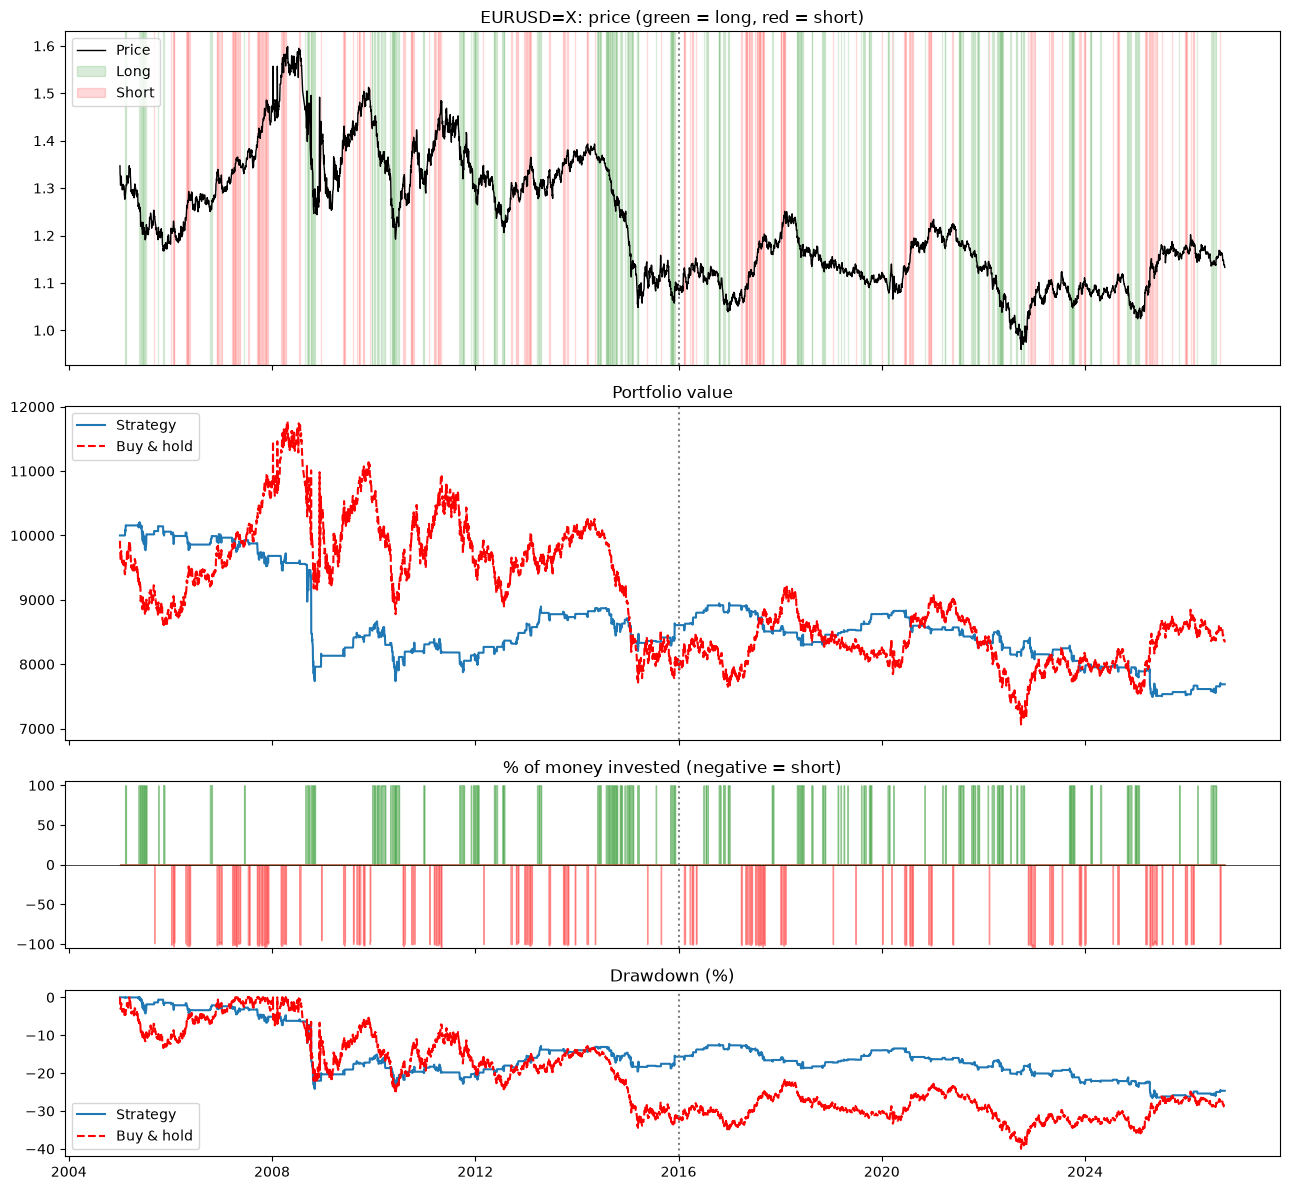

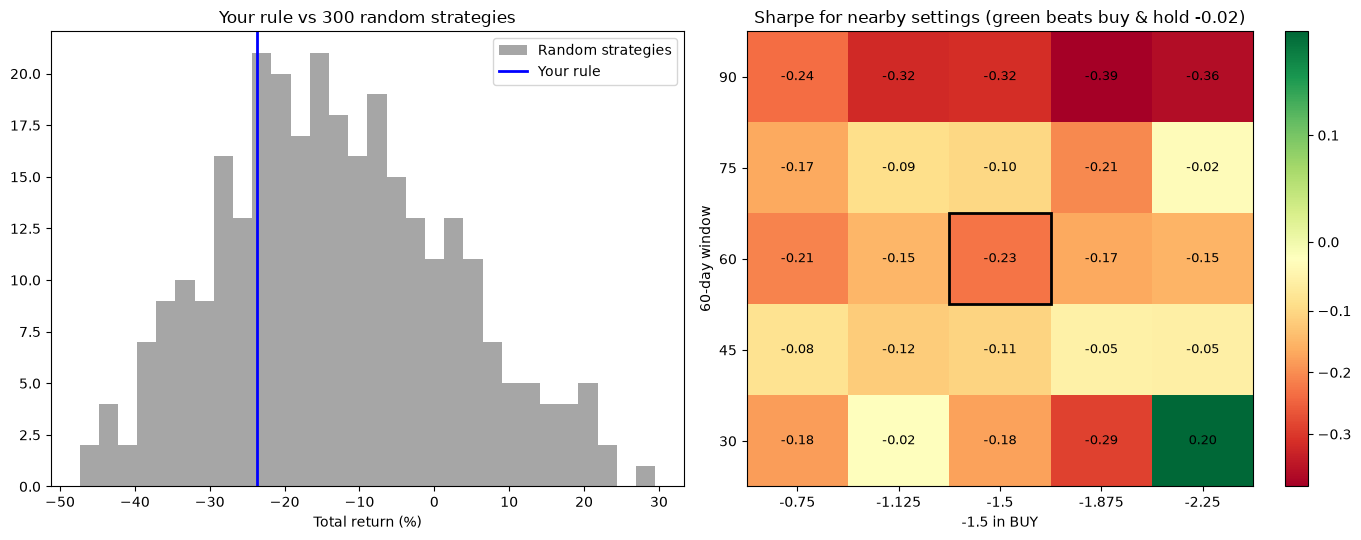

In [54]:
def run_study(tickers, start, end, settings, split_date, advanced):
    print_settings(tickers, start, end, settings, split_date, advanced)
    rows = []
    for ticker in tickers:
        print(f"\nLoading {ticker}...")
        try:
            prices = load_prices(ticker, start, end)
            r = analyse_ticker(prices, start, end, settings, split_date, advanced)
        except Exception as e:
            print(f"Skipped {ticker}: {e}")
            continue

        traded = print_rule_check(ticker, r, settings)
        print_report(ticker, r)
        if traded:
            print_breakdown(r)
        print_improvement(r["variants"])
        print_verdict(r)

        plot_results(ticker, r, split_date, compact=not advanced)
        if advanced:
            plot_checks(ticker, r)
        plt.show()
        rows.append(summary_row(ticker, r))

    if rows:
        print_summary(rows)


def default_cover(short_rule):
    return re.sub(r"^SHORT", "COVER", flip_rule(short_rule))


def custom_study():
    print(HELP)
    d = s = CUSTOM_DEFAULTS
    advanced = ask("Mode (q = quick, a = advanced)", "q", lambda t: t.lower().startswith("a"))
    tickers = ask("Tickers (e.g. EURUSD=X, SPY, AAPL)", ", ".join(d["tickers"]), as_tickers)
    start = ask("Start date (YYYY-MM-DD)", d["start"], as_date)
    end = ask("End date (YYYY-MM-DD)", date.today().isoformat(), as_date)
    settings = {
        "buy_rule": ask("Buy rule (e.g. BUY IF PRICE > MA200)", s["buy_rule"], validate_rule),
        "sell_rule": ask("Sell rule (e.g. SELL IF PRICE < MA200)", s["sell_rule"], validate_rule),
    }

    if advanced:
        wants_short = ask("Shorting (y/n)", "y" if s["short_rule"] else "n", as_yes)
        short_rule = ask("Short rule (e.g. SHORT IF PRICE < MA200)", s["short_rule"], validate_rule) if wants_short else ""
    else:
        short_rule = ask("Short rule (e.g. SHORT IF PRICE < MA200, blank for none)", "", validate_rule)
    if parse_rule(short_rule) is not None:
        settings["short_rule"] = short_rule
        settings["cover_rule"] = ask("Cover rule (e.g. COVER IF PRICE > MA200)", default_cover(short_rule), validate_rule)
    else:
        settings.update({"short_rule": "", "cover_rule": ""})

    settings["cost_pct"] = ask("Cost per trade % (e.g. 0.02 for FX, 0.1 for stocks)", s["cost_pct"], as_non_negative)

    split_date = None
    if advanced:
        settings.update({
            "short_fee_pct": (ask("Borrow fee % per year (e.g. 0 for FX, 0.5 for stocks)",
                                  s["short_fee_pct"], as_non_negative) if settings["short_rule"] else 0.0),
            "size_rule": ask("Size rule (e.g. SIZE BY RSI14 FROM 40 TO 20, blank for none)", "", validate_size),
            "initial": ask("Starting money (e.g. 10000)", s["initial"], as_positive),
            "position_pct": ask("Max % invested (e.g. 100)", s["position_pct"], as_positive),
            "target_vol_pct": ask("Target volatility % (e.g. 15, blank for none)", "", as_optional_positive),
            "rebalance_pct": ask("Rebalance band % (e.g. 10)", s["rebalance_pct"], as_non_negative),
            "stop_loss_pct": ask("Stop loss % (e.g. 5, blank for none)", "", as_optional_positive),
            "take_profit_pct": ask("Take profit % (e.g. 10, blank for none)", "", as_optional_positive),
        })
        split_date = ask("Train/test split date (YYYY-MM-DD, or none)", d["split_date"], as_optional_date)
        if split_date and not (start < split_date < end):
            print("Split date is outside the test window, so no split.")
            split_date = None
    else:
        settings.update(QUICK_DEFAULTS)
        print("\nOther settings use defaults (10,000 starting money, fully invested, no stops).")

    run_study(tickers, start, end, settings, split_date, advanced)


def main():
    print("Backtester v5")
    print(DEFAULT_STUDY["physics"])
    choice = input("\nEnter to run the pendulum study, or C for your own rules: ").strip().upper()
    if choice.startswith("C"):
        custom_study()
    else:
        d = DEFAULT_STUDY
        run_study(d["tickers"], d["start"], d["end"], dict(d["settings"]), d["split_date"], advanced=True)


main()